# From Mock Chi

This integration test is from a Chi data packet, with a minimum of 1.0, and a minimum at the center of the parameter space. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import pyRaven as rav

## 1. Generating a Mock Chi object

11.0
[8.0427598  7.35542996 6.75637797 6.2770024  5.9575482  5.8423286
 5.9575482  6.2770024  6.75637797 7.35542996]
[8.0427598  7.35542996 6.75637797 6.2770024  5.9575482  5.8423286
 5.9575482  6.2770024  6.75637797 7.35542996]
[8.0427598  7.35542996 6.75637797 6.2770024  5.9575482  5.8423286
 5.9575482  6.2770024  6.75637797 7.35542996]
[8.0427598  7.35542996 6.75637797 6.2770024  5.9575482  5.8423286
 5.9575482  6.2770024  6.75637797 7.35542996]


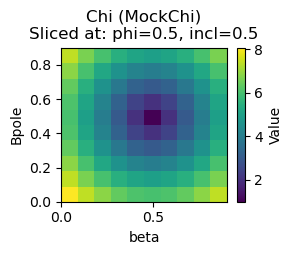

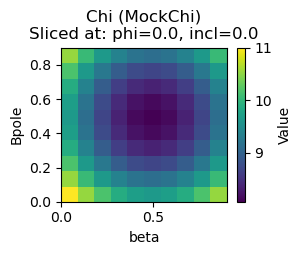

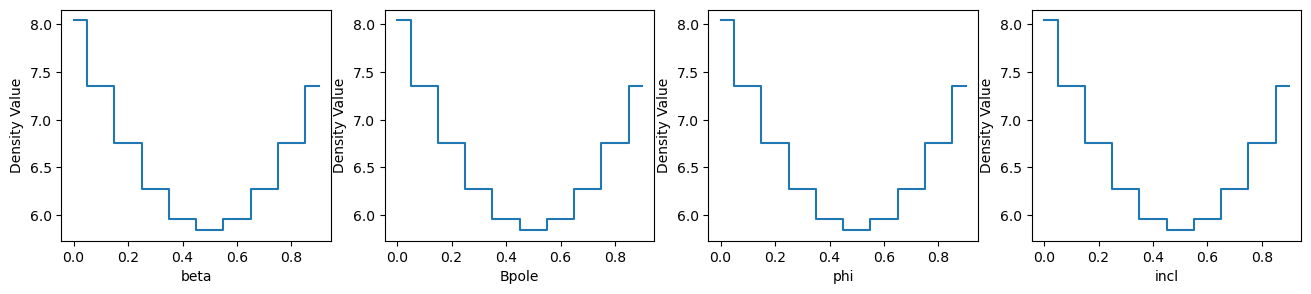

In [2]:
# Setting up the grid 
# Remember, the coordinates are the left edges of bins
# therefore the last point shouldn't be 90 for angles
# The range of angles should be 0-360 for phi, but this is just a test.
beta = np.arange(0,0.99,0.1)
Bpole = np.arange(0,0.99,0.1)
phi = np.arange(0,0.99,0.1)
incl = np.arange(0,0.99,0.1)

prob = (
        (beta[  (slice(None), np.newaxis, np.newaxis, np.newaxis)]-0.5)**2 + 
        (Bpole[ (np.newaxis, slice(None), np.newaxis, np.newaxis)]-0.5)**2 + 
        (phi[   (np.newaxis, np.newaxis, slice(None), np.newaxis)]-0.5)**2 + 
        (incl[  (np.newaxis, np.newaxis, np.newaxis, slice(None))]-0.5)**2 
        )**0.5*10 +1.0


chi = rav.BayesObjects2.Chi(prob, beta_coord=beta, Bpole_coord=Bpole, 
                                  phi_coord=phi, incl_coord=incl, obsID='MockChi')

fig, ax = chi.plot_2d_slice(phi_coord=5, incl_coord=5)
fig.set_size_inches(fig.get_size_inches()[0]/3, fig.get_size_inches()[1]/3)

fig, ax = chi.plot_2d_slice(phi_coord=0, incl_coord=0)
fig.set_size_inches(fig.get_size_inches()[0]/3, fig.get_size_inches()[1]/3)

print(chi.prob.max())

fig, ax = chi.plot_1d_marginals()


## 2. Likelihood object

In [ ]:
N = 20
avg_ln_err = np.log(0.01)
lnlh = rav.BayesObjects2.LnLikelihood.from_redchi2(chi, 
                                                   num_datapoints=N, avg_ln_error=avg_ln_err, 
                                                   noise_coord=[0.5, 1, 2])

fig, ax = lnlh.plot_2d_slice(phi_coord=5, incl_coord=5, noise_coord=1)
fig.set_size_inches(fig.get_size_inches()[0]/3, fig.get_size_inches()[1]/3)

fig, ax = lnlh.plot_2d_slice(phi_coord=0, incl_coord=0, noise_coord=1)
fig.set_size_inches(fig.get_size_inches()[0]/3, fig.get_size_inches()[1]/3)

print(lnlh.prob.min(), lnlh.prob.max())

fig, ax = lnlh.plot_1d_marginals()